Veri Hazırlığı Tamamlandı! Toplam Analiz Edilen Satır: 753

--- Eksik Veri Kontrolü ---
CharacteristicName
pH            0
Sulfate       0
Potability    0
dtype: int64

--- İstatistiksel Özet ---


CharacteristicName,pH,Sulfate,Potability
count,753.000000,753.000000,753.000000
mean,5.947244,14.556985,0.379814
std,1.239114,88.201719,0.485663
min,4.105000,1.100000,0.000000
25%,4.700000,2.200000,0.000000
50%,5.865000,4.100000,0.000000
75%,7.100000,7.000000,1.000000
max,9.100000,1265.000000,1.000000



--- Sınıflara Göre Ortalama Değerler ---


CharacteristicName,pH,Sulfate
Potability,,
0,5.135821,13.518701
1,7.272191,16.252366


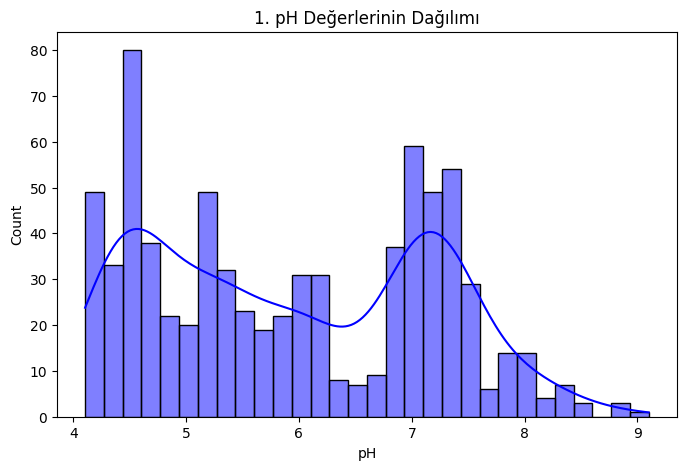

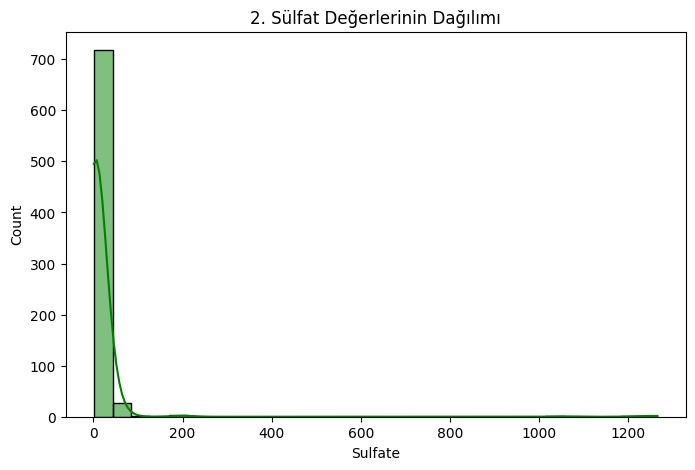

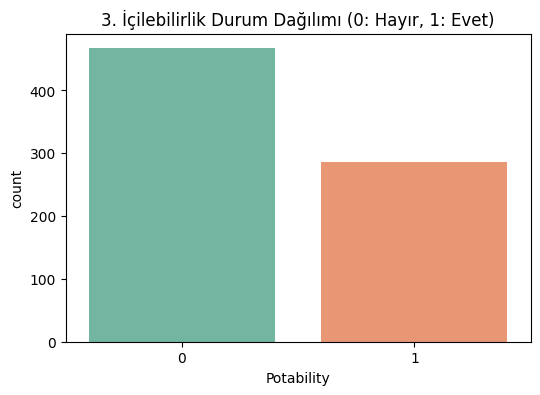

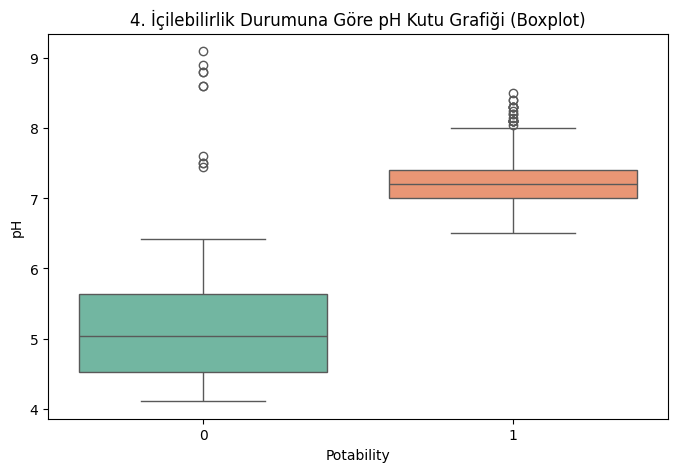

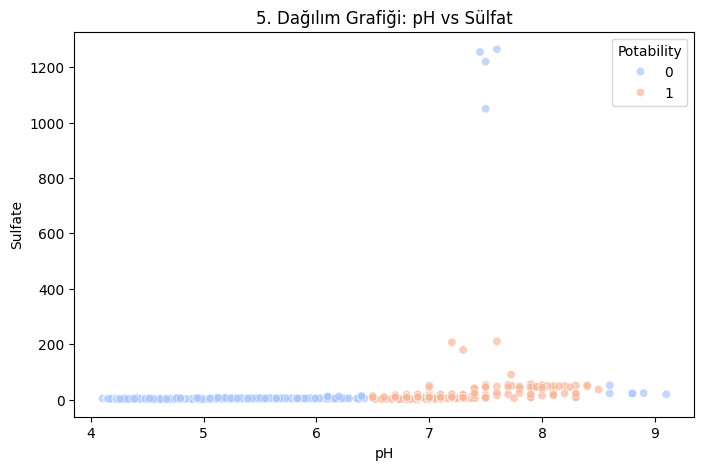

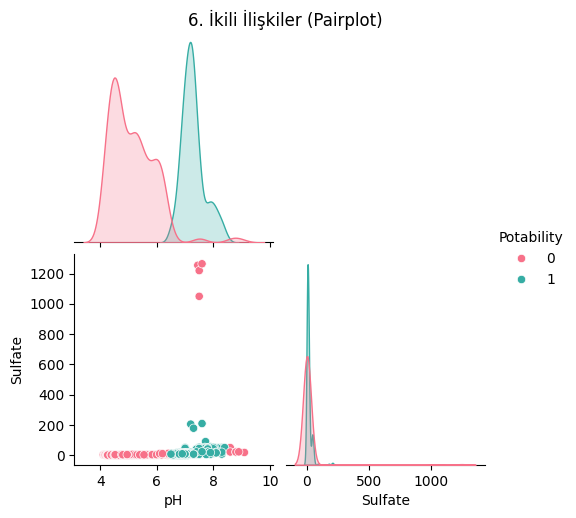

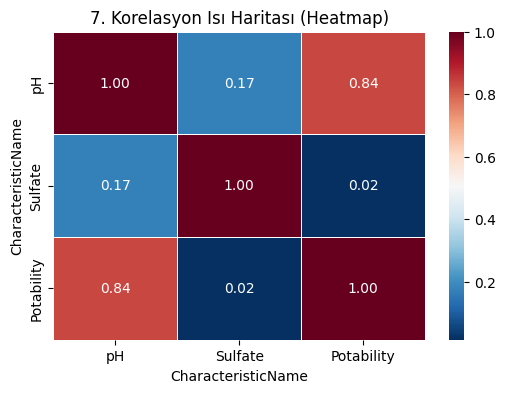

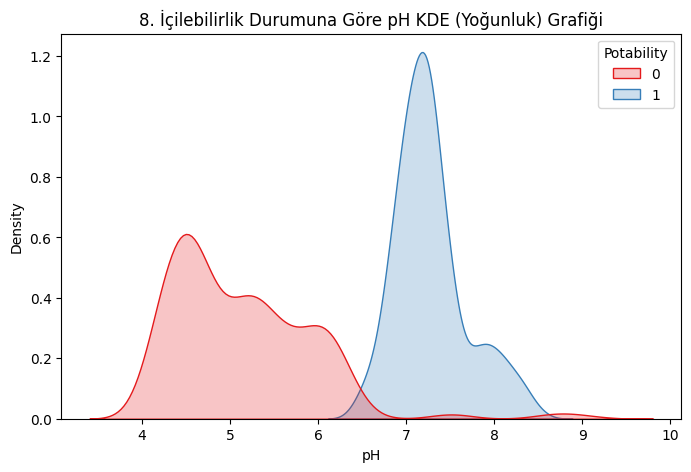


Makine Öğrenmesi Modelleri Eğitiliyor...

--- Logistic Regression Sonuçları ---
Accuracy : 0.987
Precision: 0.966
Recall   : 1.000
F1-score : 0.983
ROC-AUC  : 0.979

--- Random Forest (Baseline) Sonuçları ---
Accuracy : 1.000
Precision: 1.000
Recall   : 1.000
F1-score : 1.000
ROC-AUC  : 1.000



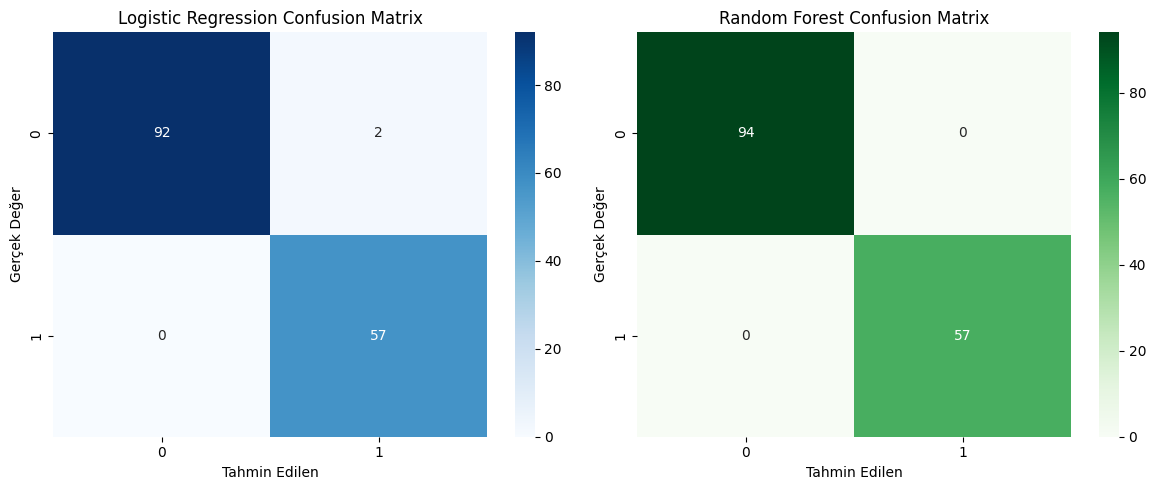

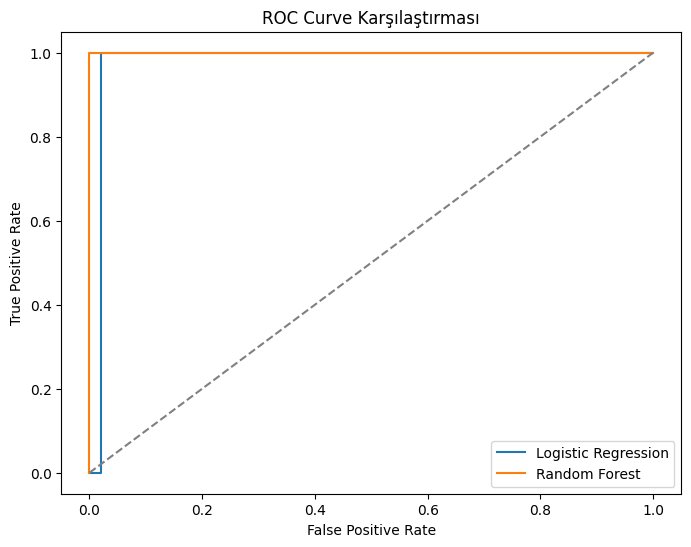

NİHAİ İYİLEŞTİRİLMİŞ MODEL (PART B) ÇALIŞTIRILIYOR...
--- Optimized Pipeline (SMOTE + Random Forest) Sonuçları ---
Accuracy : 1.000
Precision: 1.000
Recall   : 1.000
F1-score : 1.000
ROC-AUC  : 1.000



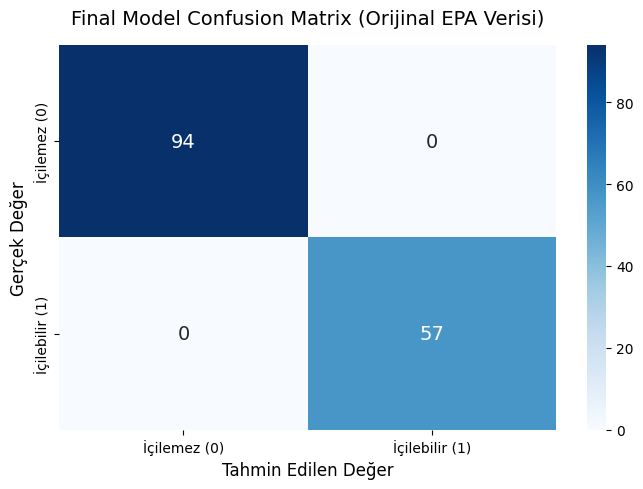


 TÜM İŞLEMLER BAŞARIYLA TAMAMLANDI!


In [18]:
# ==============================================================================
# WATER POTABILITY PREDICTION - FULL ML PIPELINE (EPA NEW YORK DATASET)
# ==============================================================================

# ------------------------------------------------------------------------------
# 1. KÜTÜPHANELERİN YÜKLENMESİ
# ------------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import warnings
warnings.filterwarnings('ignore')



# ------------------------------------------------------------------------------
# 2. VERİ YÜKLEME VE HEDEF DEĞİŞKEN (POTABILITY)
# ------------------------------------------------------------------------------
dosya_adi = "NewYork_Water_Results.csv"
df_raw = pd.read_csv(dosya_adi, low_memory=False)

# Gerekli sütunları alma ve temizleme
cols_to_keep = ['MonitoringLocationIdentifier', 'ActivityStartDate', 'CharacteristicName', 'ResultMeasureValue']
df_filtered = df_raw[cols_to_keep].dropna(subset=['ResultMeasureValue']).copy()
df_filtered['ResultMeasureValue'] = pd.to_numeric(df_filtered['ResultMeasureValue'], errors='coerce')

# Veriyi Wide formata (sütunlara) çevirme
df_pivot = df_filtered.pivot_table(
    index=['MonitoringLocationIdentifier', 'ActivityStartDate'],
    columns='CharacteristicName',
    values='ResultMeasureValue',
    aggfunc='mean'
).reset_index()

# Potability Kuralları (WHO: pH 6.5-8.5 ve Sülfat <= 250)
def label_potability(row):
    try:
        ph = float(row.get('pH', np.nan))
        sulfate = float(row.get('Sulfate', np.nan))
        if pd.isna(ph) or pd.isna(sulfate): return np.nan
        if (6.5 <= ph <= 8.5) and (sulfate <= 250): return 1
        else: return 0
    except:
        return np.nan

df_pivot['Potability'] = df_pivot.apply(label_potability, axis=1)
df_final = df_pivot.dropna(subset=['Potability']).copy()
df_final['Potability'] = df_final['Potability'].astype(int)

# Sadece analize girecek sütunları ayırma
df = df_final[['pH', 'Sulfate', 'Potability']].copy()
print(f"Veri Hazırlığı Tamamlandı! Toplam Analiz Edilen Satır: {len(df)}\n")

# ------------------------------------------------------------------------------
# 3. KEŞİFSEL VERİ ANALİZİ (EDA) VE İSTATİSTİKLER
# ------------------------------------------------------------------------------
print("--- Eksik Veri Kontrolü ---")
print(df.isnull().sum())

print("\n--- İstatistiksel Özet ---")
display(df.describe())

print("\n--- Sınıflara Göre Ortalama Değerler ---")
display(df.groupby('Potability').mean())

# GÖRSELLEŞTİRMELER
plt.figure(figsize=(8,5))
sns.histplot(df['pH'], kde=True, bins=30, color='blue')
plt.title("1. pH Değerlerinin Dağılımı")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df['Sulfate'], kde=True, bins=30, color='green')
plt.title("2. Sülfat Değerlerinin Dağılımı")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Potability', palette='Set2')
plt.title("3. İçilebilirlik Durum Dağılımı (0: Hayır, 1: Evet)")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Potability', y='pH', palette='Set2')
plt.title("4. İçilebilirlik Durumuna Göre pH Kutu Grafiği (Boxplot)")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='pH', y='Sulfate', hue='Potability', palette='coolwarm', alpha=0.7)
plt.title("5. Dağılım Grafiği: pH vs Sülfat")
plt.show()

sns.pairplot(df, hue='Potability', palette='husl', corner=True)
plt.suptitle("6. İkili İlişkiler (Pairplot)", y=1.02)
plt.show()

plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap='RdBu_r', fmt='.2f', linewidths=0.5)
plt.title("7. Korelasyon Isı Haritası (Heatmap)")
plt.show()

plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='pH', hue='Potability', fill=True, palette='Set1', common_norm=False)
plt.title("8. İçilebilirlik Durumuna Göre pH KDE (Yoğunluk) Grafiği")
plt.show()

# ------------------------------------------------------------------------------
# 4. TEMEL MODELLERİN EĞİTİLMESİ VE KARŞILAŞTIRILMASI (BASELINE)
# ------------------------------------------------------------------------------
print("\nMakine Öğrenmesi Modelleri Eğitiliyor...\n")

X = df.drop("Potability", axis=1)
y = df["Potability"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model 1: Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

# Model 2: Random Forest
rf = RandomForestClassifier(random_state=42, n_estimators=200)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

def evaluate_model(name, y_test, y_pred, y_prob):
    print(f"--- {name} Sonuçları ---")
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
    print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.3f}")
    print(f"Recall   : {recall_score(y_test, y_pred, zero_division=0):.3f}")
    print(f"F1-score : {f1_score(y_test, y_pred, zero_division=0):.3f}")
    print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.3f}\n")

evaluate_model("Logistic Regression", y_test, y_pred_lr, y_prob_lr)
evaluate_model("Random Forest (Baseline)", y_test, y_pred_rf, y_prob_rf)

# Yan Yana Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Logistic Regression Confusion Matrix")
axes[0].set_xlabel("Tahmin Edilen")
axes[0].set_ylabel("Gerçek Değer")

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title("Random Forest Confusion Matrix")
axes[1].set_xlabel("Tahmin Edilen")
axes[1].set_ylabel("Gerçek Değer")
plt.tight_layout()
plt.show()

# ROC Curve Karşılaştırması
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0,1], [0,1], linestyle="--", color='grey')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Karşılaştırması")
plt.legend()
plt.show()

# ------------------------------------------------------------------------------
# 5. NİHAİ MODEL (SMOTE EKLENMİŞ, DEPLOYMENT'A HAZIR PİPELİNE)
# ------------------------------------------------------------------------------
print("="*60)
print("NİHAİ İYİLEŞTİRİLMİŞ MODEL (PART B) ÇALIŞTIRILIYOR...")
print("="*60)

final_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42))
])

final_pipeline.fit(X_train, y_train)
y_pred_final = final_pipeline.predict(X_test)
y_prob_final = final_pipeline.predict_proba(X_test)[:, 1]

evaluate_model("Optimized Pipeline (SMOTE + Random Forest)", y_test, y_pred_final, y_prob_final)

# Nihai Modelin Confusion Matrix'i
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['İçilemez (0)', 'İçilebilir (1)'],
            yticklabels=['İçilemez (0)', 'İçilebilir (1)'], annot_kws={"size": 14})
plt.title('Final Model Confusion Matrix (Orijinal EPA Verisi)', fontsize=14, pad=15)
plt.ylabel('Gerçek Değer', fontsize=12)
plt.xlabel('Tahmin Edilen Değer', fontsize=12)
plt.tight_layout()
plt.show()

print("\n TÜM İŞLEMLER BAŞARIYLA TAMAMLANDI!")